# Analyse des systèmes éducatifs
## Recommandation de pays pour une expansion internationale

Ce notebook présente une démarche complète de préparation, d’analyse et de sélection de pays à partir du dataset **EdStats**.

L’objectif est de construire une **base quantitative d’aide à la décision** pour une réflexion d’expansion à l’international, en s’appuyant sur des indicateurs :

- éducatifs ;
- numériques ;
- socio-économiques.

Le notebook a été réorganisé pour être :

- lisible ;
- reproductible ;
- conforme à l’énoncé ;
- exploitable dans JupyterLab comme dans VS Code.

## Plan du notebook

1. Chargement et exploration des fichiers  
2. Identification et suppression des faux pays  
3. Réduction du périmètre des indicateurs  
4. Réduction du périmètre des années  
5. Mesure de la richesse des données  
6. Agrégation à la maille *un pays = une ligne*  
7. Corrélations et suppression des indicateurs redondants  
8. Analyse univariée des indicateurs finaux  
9. Construction d’un score pays  
10. Affichage final des pays recommandés

## Librairies utilisées et rôle de Pandas / NumPy / Matplotlib

Dans ce notebook :

- **Pandas** sert à charger, filtrer, transformer et agréger les tableaux de données (`read_csv`, `groupby`, `pivot_table`, `merge`, `melt`, `isna`, `value_counts`, etc.).
- **NumPy** sert à faire des opérations numériques rapides, notamment pour la normalisation et certains calculs matriciels.
- **Matplotlib** sert à construire des graphiques simples et lisibles : bar charts, histogrammes, boxplots et graphiques finaux.
- **Seaborn** est utilisé en complément pour la heatmap des corrélations.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Localisation automatique des fichiers

Le notebook cherche automatiquement les fichiers EdStats dans plusieurs emplacements possibles :

- le dossier courant ;
- le dossier parent ;
- un sous-dossier `cleaned/` si présent ;
- la racine du projet si Jupyter est lancé depuis `notebooks/`.

Cette approche évite de coder en dur un chemin absolu.

In [2]:
def trouver_dossier_donnees():
    candidats = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "cleaned",
        Path.cwd().parent / "cleaned",
        Path.cwd().parent.parent,
        Path.cwd().parent.parent / "cleaned",
    ]

    fichiers_attendus = {
        "EdStatsCountry.csv",
        "EdStatsCountry-Series.csv",
        "EdStatsData.csv",
        "EdStatsFootNote.csv",
        "EdStatsSeries.csv",
    }

    for dossier in candidats:
        if dossier.exists():
            contenu = {p.name for p in dossier.iterdir() if p.is_file()}
            if fichiers_attendus.issubset(contenu):
                return dossier

    raise FileNotFoundError(
        "Impossible de trouver les fichiers EdStats. "
        "Placez le notebook dans le projet ou lancez Jupyter depuis la racine du projet."
    )

base_path = trouver_dossier_donnees()
print("Dossier utilisé :", base_path)
print("\nCSV détectés :")
for nom in sorted([p.name for p in base_path.iterdir() if p.is_file() and p.suffix == ".csv"]):
    print("-", nom)

Dossier utilisé : /Users/vincentdesmouceaux/dev/P2_educatif_system_analysis

CSV détectés :
- EdStatsCountry-Series.csv
- EdStatsCountry.csv
- EdStatsData.csv
- EdStatsFootNote.csv
- EdStatsSeries.csv
- df_final_decorrele.csv


## Chargement des fichiers

Je charge maintenant les cinq fichiers principaux du dataset :

- `Country`
- `Country-Series`
- `Data`
- `FootNote`
- `Series`

In [3]:
country = pd.read_csv(base_path / "EdStatsCountry.csv")
country_series = pd.read_csv(base_path / "EdStatsCountry-Series.csv")
data = pd.read_csv(base_path / "EdStatsData.csv")
footnote = pd.read_csv(base_path / "EdStatsFootNote.csv")
series = pd.read_csv(base_path / "EdStatsSeries.csv")

print("country        :", country.shape)
print("country_series :", country_series.shape)
print("data           :", data.shape)
print("footnote       :", footnote.shape)
print("series         :", series.shape)

country        : (241, 32)
country_series : (613, 4)
data           : (886930, 70)
footnote       : (643638, 5)
series         : (3665, 21)


# 1. Exploration initiale des fichiers

Pour chaque table, je vérifie :

- les premières lignes ;
- le nombre de lignes et de colonnes ;
- les doublons ;
- les valeurs manquantes ;
- les colonnes inutilisables ;
- les statistiques descriptives pour les variables numériques ;
- un aperçu des variables catégorielles.

L’idée est de **comprendre la structure** des données avant de commencer le nettoyage.

In [4]:
def explorer_nettoyer_dataframe(df, nom_fichier):
    print("\n" + "=" * 70)
    print(f"Exploration de : {nom_fichier}")
    print("=" * 70)

    print("\nPremières lignes :")
    display(df.head())

    nb_lignes, nb_colonnes = df.shape
    print(f"\nNombre de lignes   : {nb_lignes}")
    print(f"Nombre de colonnes : {nb_colonnes}")

    nb_doublons = df.duplicated().sum()
    print(f"\nNombre de doublons : {nb_doublons}")

    df = df.drop_duplicates().copy()
    print(f"Nombre de lignes après suppression des doublons : {df.shape[0]}")

    proportion_nan = (df.isna().sum() / len(df)) * 100
    print("\nProportion de valeurs manquantes par colonne :")
    display(proportion_nan.sort_values(ascending=False).to_frame(name="pct_nan"))

    colonnes_inutilisables = proportion_nan[proportion_nan == 100].index.tolist()
    print("\nColonnes inutilisables :", colonnes_inutilisables)

    if colonnes_inutilisables:
        df = df.drop(columns=colonnes_inutilisables)
        print("Colonnes supprimées.")
    else:
        print("Aucune colonne supprimée.")

    colonnes_numeriques = df.select_dtypes(include="number").columns
    if len(colonnes_numeriques) > 0:
        print("\nStatistiques descriptives des colonnes numériques :")
        display(df[colonnes_numeriques].describe())

    colonnes_categorielles = df.select_dtypes(include=["object", "string"]).columns
    if len(colonnes_categorielles) > 0:
        print("\nAperçu des variables catégorielles :")
        for col in colonnes_categorielles[:5]:
            print(f"\nColonne : {col}")
            display(df[col].value_counts(dropna=False).head(10))

    return df

In [5]:
country = explorer_nettoyer_dataframe(country, "EdStatsCountry.csv")
country_series = explorer_nettoyer_dataframe(country_series, "EdStatsCountry-Series.csv")
data = explorer_nettoyer_dataframe(data, "EdStatsData.csv")
footnote = explorer_nettoyer_dataframe(footnote, "EdStatsFootNote.csv")
series = explorer_nettoyer_dataframe(series, "EdStatsSeries.csv")


Exploration de : EdStatsCountry.csv

Premières lignes :


,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,National accounts reference year,SNA price valuation,Lending category,Other groups,System of National Accounts,Alternative conversion factor,PPP survey year,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,2000,NaN,Value added at basic prices (VAB),NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,"IMF Balance of Payments Manual, 6th edition.",NaN,Special trade system,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,2002/03,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,General trade system,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,2002,NaN,Value added at producer prices (VAP),IBRD,NaN,Country uses the 1993 System of National Accou...,1991–96,2005,"IMF Balance of Payments Manual, 6th edition.",Actual,Special trade system,Budgetary central government,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,Original chained constant price data are resca...,1996.0,Value added at basic prices (VAB),IBRD,NaN,Country uses the 1993 System of National Accou...,NaN,Rolling,"IMF Balance of Payments Manual, 6th edition.",Actual,General trade system,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,1990,NaN,NaN,NaN,NaN,Country uses the 1968 System of National Accou...,NaN,NaN,NaN,NaN,Special trade system,NaN,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN



Nombre de lignes   : 241
Nombre de colonnes : 32

Nombre de doublons : 0
Nombre de lignes après suppression des doublons : 241

Proportion de valeurs manquantes par colonne :


,pct_nan
Unnamed: 31,100.000000
National accounts reference year,86.721992
Alternative conversion factor,80.497925
Other groups,75.933610
Latest industrial data,55.601660
Vital registration complete,53.941909
External debt Reporting status,48.547718
Latest household survey,41.493776
Latest agricultural census,41.078838
Lending category,40.248963



Colonnes inutilisables : ['Unnamed: 31']
Colonnes supprimées.

Statistiques descriptives des colonnes numériques :


...

Indicator Name
Barro-Lee: Percentage of female population age 15-19 with no education    1
Barro-Lee: Percentage of population age 15-19 with no education           1
Barro-Lee: Percentage of female population age 15+ with no education      1
Barro-Lee: Percentage of population age 15+ with no education             1
Barro-Lee: Percentage of female population age 20-24 with no education    1
Barro-Lee: Percentage of population age 20-24 with no education           1
Barro-Lee: Percentage of female population age 25-29 with no education    1
Barro-Lee: Percentage of population age 25-29 with no education           1
Barro-Lee: Percentage of female population age 25+ with no education      1
Barro-Lee: Percentage of population age 25+ with no education             1
Name: count, dtype: int64


Colonne : Short definition


Short definition
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   1509
Data Interpretation: 1=Latent; 2=Emerging; 3=Established; 4=Advanced. For additional information, visit the SABER: (website: http://saber.worldbank.org/index.cfm                                                                                                           


Colonne : Long definition


Long definition
Data Interpretation: 1=Latent; 2=Emerging; 3=Established; 4=Advanced. For additional information, visit the SABER: (website: http://saber.worldbank.org/index.cfm                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     215
Percentage of students who were unable to read a single word of text on the oral reading fluency subtask. The oral reading fluency/paragraph reading subtask examines students' ability to read a narrative or informational text with accuracy, with little effort, and at a 

## Visualisation rapide des valeurs manquantes

`missingno` permet d’obtenir une vue synthétique des données manquantes.  
Je l’utilise ici de manière légère sur quelques tables principales.

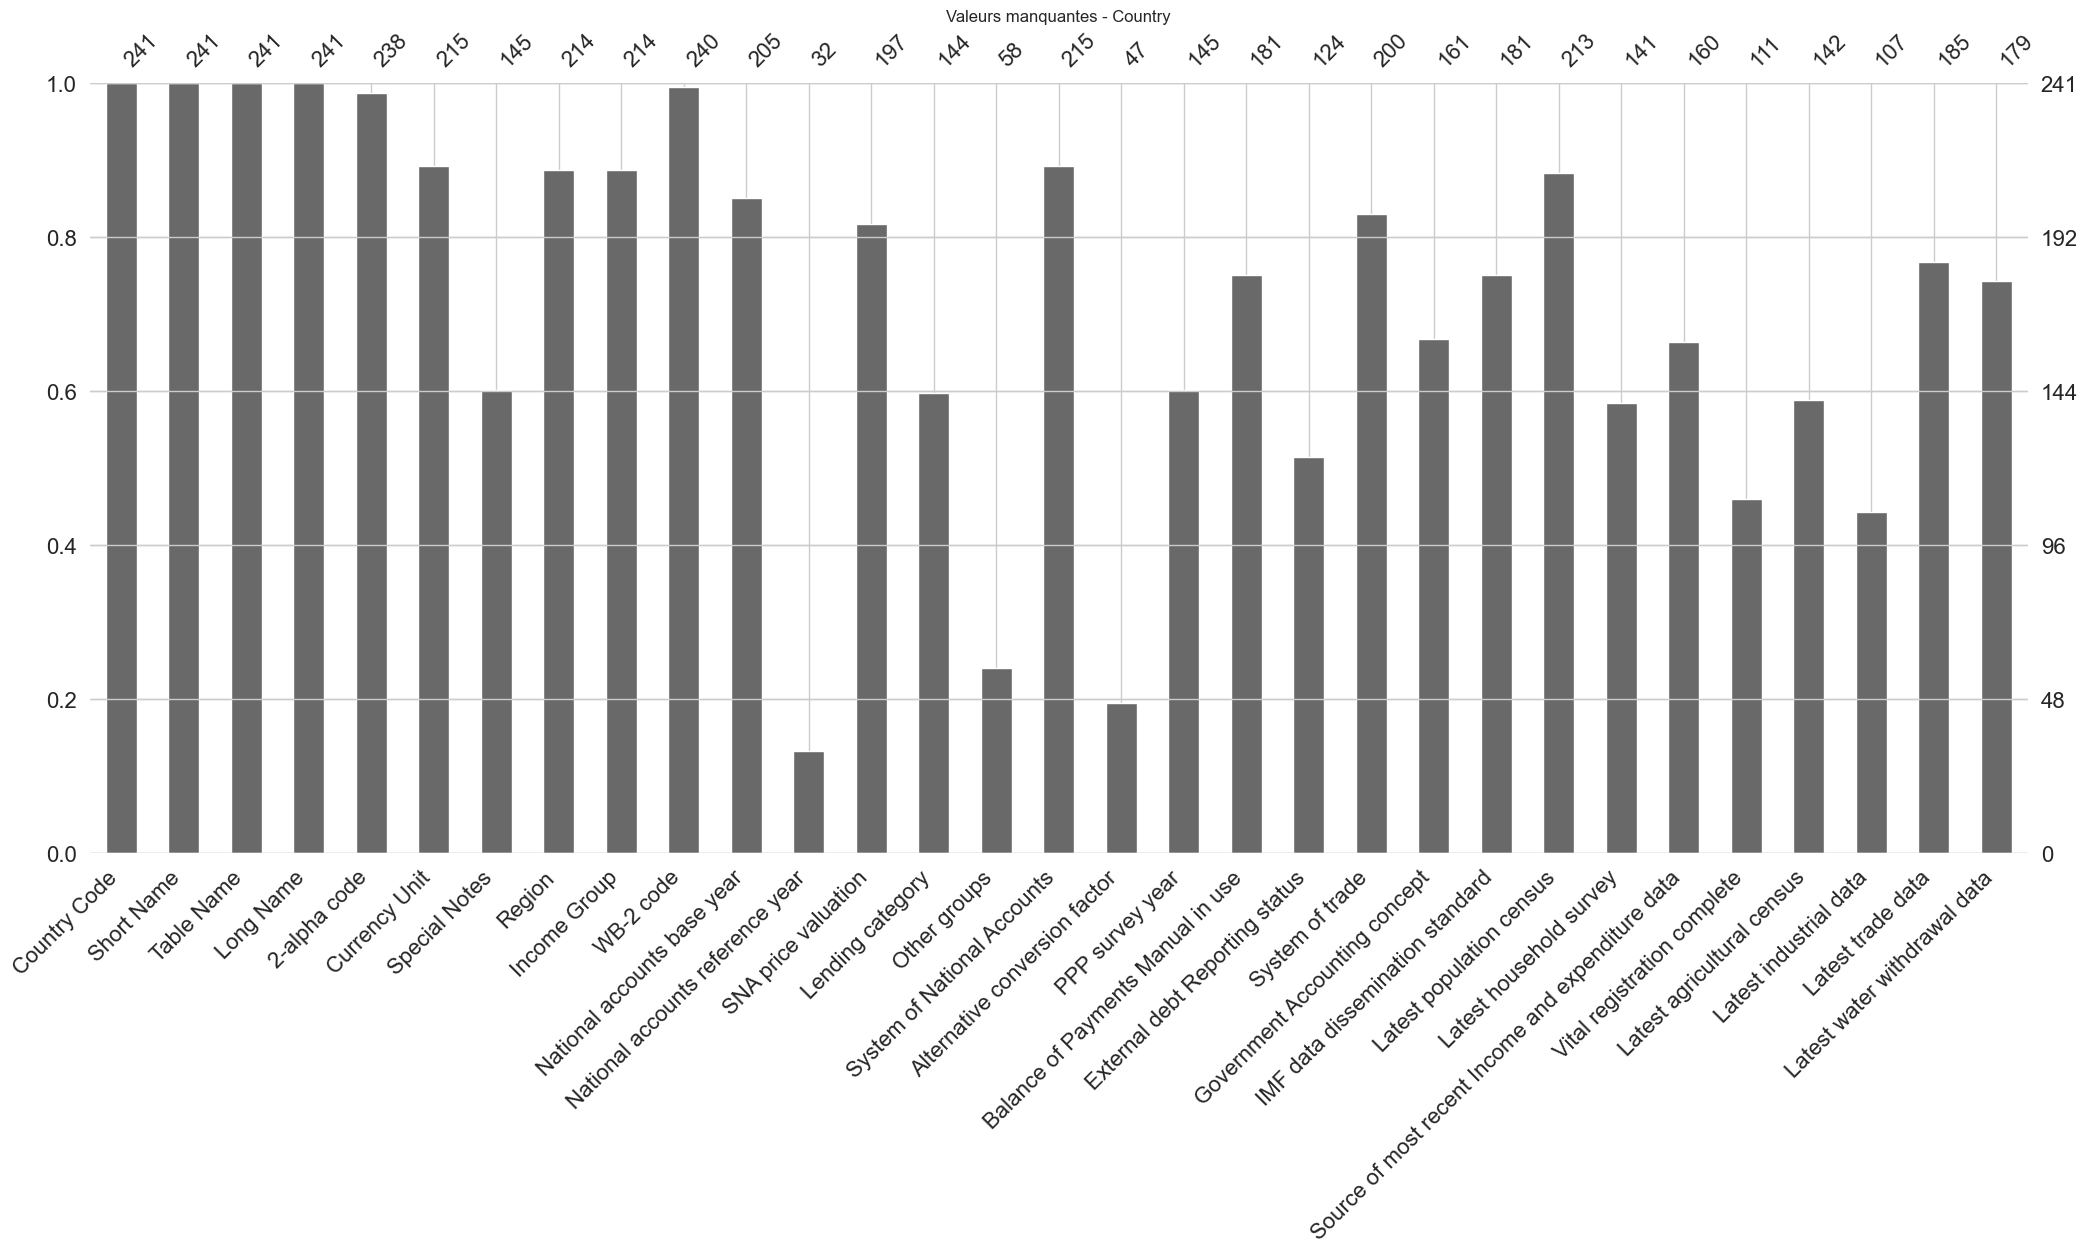

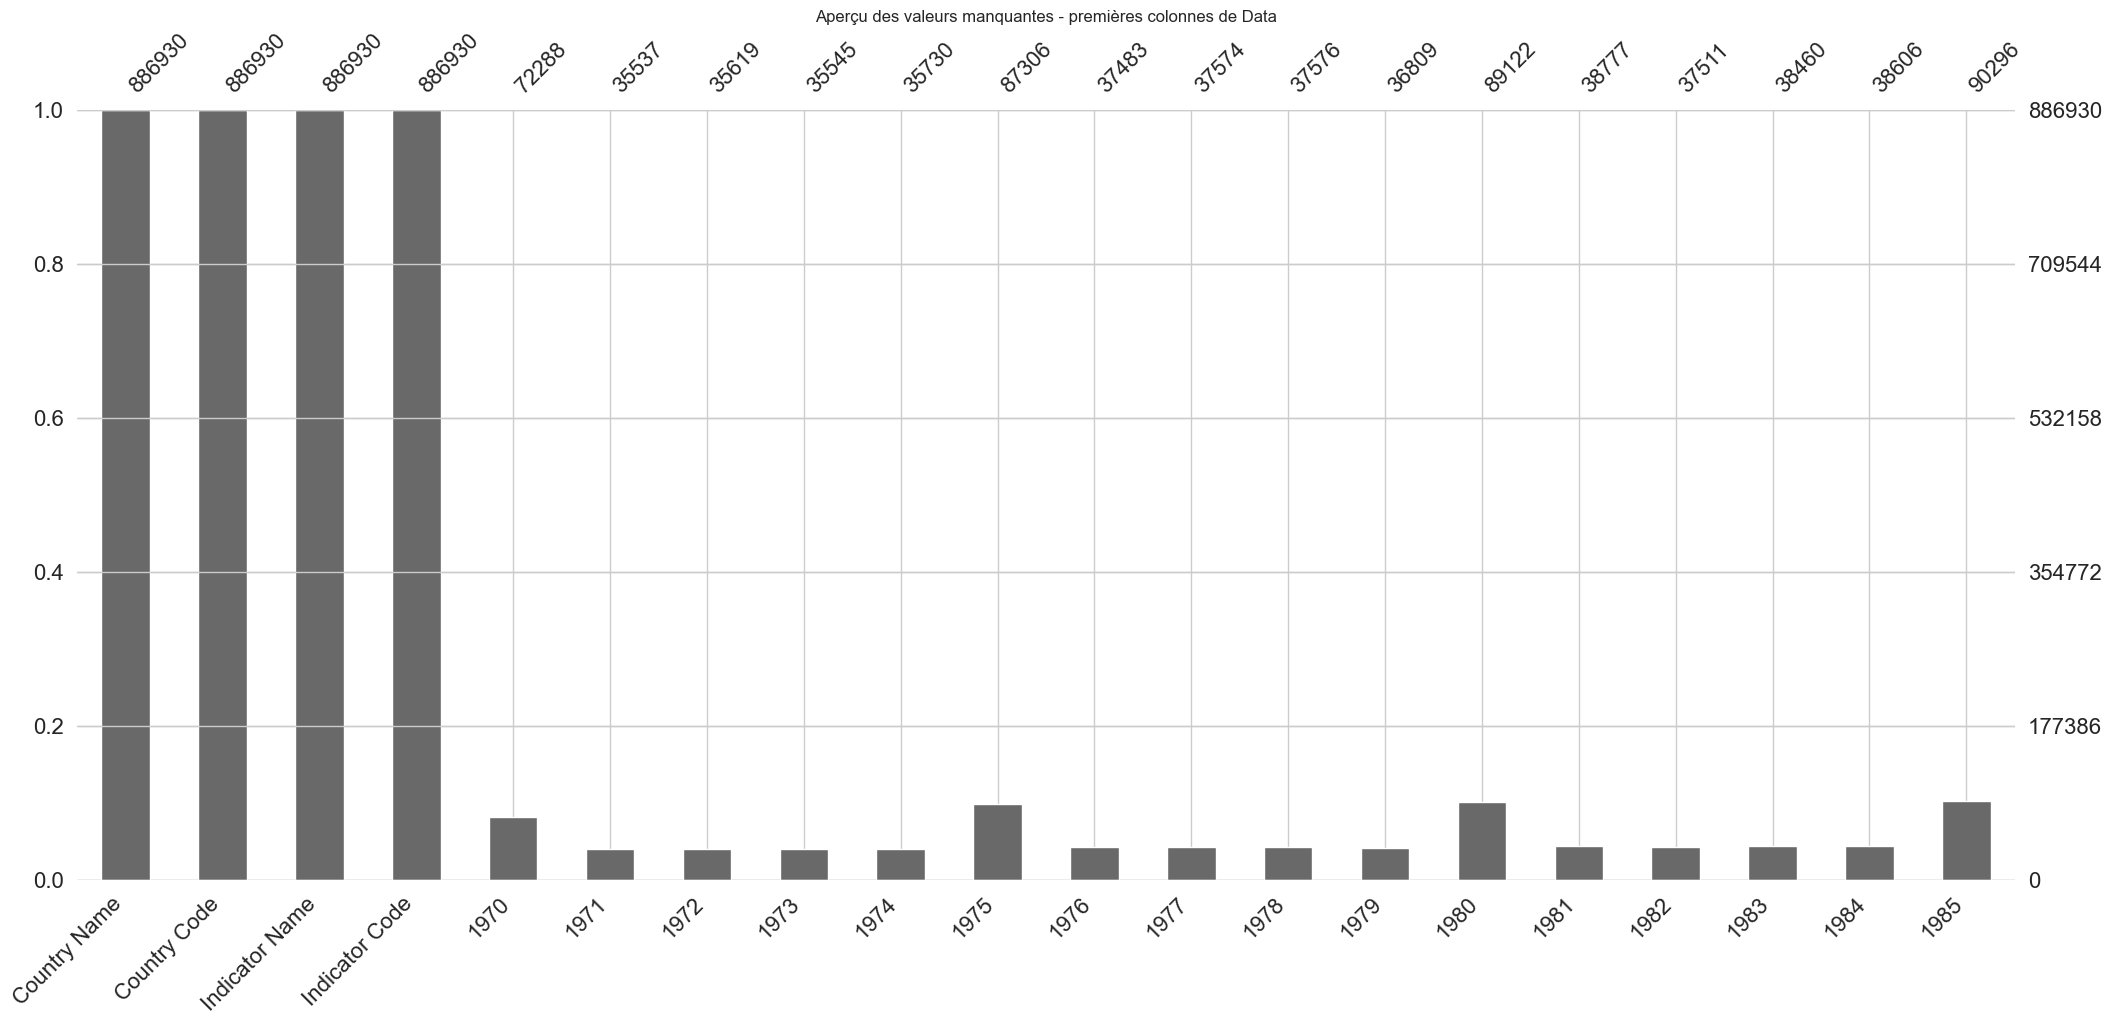

In [6]:
msno.bar(country)
plt.title("Valeurs manquantes - Country")
plt.show()

msno.bar(data.iloc[:, :20])
plt.title("Aperçu des valeurs manquantes - premières colonnes de Data")
plt.show()

# 2. Identification et suppression des faux pays

Le fichier `Country` ne contient pas uniquement des pays.  
On y trouve aussi des agrégats régionaux ou économiques comme :

- `World`
- `Arab World`
- `High income`
- `Sub-Saharan Africa`
- `Europe & Central Asia`

Pour fiabiliser l’analyse, je retire ces **faux pays** des tables où cela fait sens :
- `Country`
- `Country-Series`
- `FootNote`
- `Data`

In [7]:
print(country.columns.tolist())

colonnes_country = [
    col for col in ["Country Code", "Short Name", "Table Name", "Region", "Income Group"]
    if col in country.columns
]
display(country[colonnes_country].head(30))

['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code', 'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code', 'National accounts base year', 'National accounts reference year', 'SNA price valuation', 'Lending category', 'Other groups', 'System of National Accounts', 'Alternative conversion factor', 'PPP survey year', 'Balance of Payments Manual in use', 'External debt Reporting status', 'System of trade', 'Government Accounting concept', 'IMF data dissemination standard', 'Latest population census', 'Latest household survey', 'Source of most recent Income and expenditure data', 'Vital registration complete', 'Latest agricultural census', 'Latest industrial data', 'Latest trade data', 'Latest water withdrawal data']


,Country Code,Short Name,Table Name,Region,Income Group
0,ABW,Aruba,Aruba,Latin America & Caribbean,High income: nonOECD
1,AFG,Afghanistan,Afghanistan,South Asia,Low income
2,AGO,Angola,Angola,Sub-Saharan Africa,Upper middle income
3,ALB,Albania,Albania,Europe & Central Asia,Upper middle income
4,AND,Andorra,Andorra,Europe & Central Asia,High income: nonOECD
5,ARB,Arab World,Arab World,NaN,NaN
6,ARE,United Arab Emirates,United Arab Emirates,Middle East & North Africa,High income: nonOECD
7,ARG,Argentina,Argentina,Latin America & Caribbean,Upper middle income
8,ARM,Armenia,Armenia,Europe & Central Asia,Lower middle income
9,ASM,American Samoa,American Samoa,East Asia & Pacific,Upper middle income


## Repérage des faux pays

Une règle simple et robuste consiste à considérer comme faux pays les lignes pour lesquelles :

- `Region` est manquante ;
- ou `Income Group` est manquante.

Cette règle capture une grande partie des agrégats non-pays du dataset.

In [8]:
colonnes_faux_pays = [
    col for col in ["Country Code", "Short Name", "Table Name", "Region", "Income Group"]
    if col in country.columns
]

faux_pays = country[
    country["Region"].isna() | country["Income Group"].isna()
][colonnes_faux_pays].copy()

display(faux_pays.head(30))
print("Nombre de faux pays identifiés :", faux_pays.shape[0])

liste_faux_pays = faux_pays["Country Code"].dropna().unique().tolist()
print("Aperçu des codes supprimés :", liste_faux_pays[:20])

,Country Code,Short Name,Table Name,Region,Income Group
5,ARB,Arab World,Arab World,NaN,NaN
57,EAP,East Asia & Pacific (developing only),East Asia & Pacific,NaN,NaN
58,EAS,East Asia & Pacific (all income levels),East Asia & Pacific (all income levels),NaN,NaN
59,ECA,Europe & Central Asia (developing only),Europe & Central Asia,NaN,NaN
60,ECS,Europe & Central Asia (all income levels),Europe & Central Asia (all income levels),NaN,NaN
63,EMU,Euro area,Euro area,NaN,NaN
68,EUU,European Union,European Union,NaN,NaN
78,GIB,Gibraltar,Gibraltar,NaN,NaN
89,HIC,High income,High income,NaN,NaN
92,HPC,Heavily indebted poor countries (HIPC),Heavily indebted poor countries (HIPC),NaN,NaN


Nombre de faux pays identifiés : 27
Aperçu des codes supprimés : ['ARB', 'EAP', 'EAS', 'ECA', 'ECS', 'EMU', 'EUU', 'GIB', 'HIC', 'HPC', 'LAC', 'LCN', 'LDC', 'LIC', 'LMC', 'LMY', 'MEA', 'MIC', 'MNA', 'NAC']


## Méthode 1 — filtrage avec une liste

Ici, j’utilise une liste Python contenant les codes des faux pays.

Avec **Pandas**, l’expression :

```python
df[~df[colonne].isin(liste)]
```

signifie :
- `isin(liste)` : teste si la valeur appartient à la liste ;
- `~` : inverse la condition ;
- on ne garde donc **que les lignes valides**.

In [9]:
footnote_country_col = "CountryCode" if "CountryCode" in footnote.columns else "Country Code"

country_clean = country[~country["Country Code"].isin(liste_faux_pays)].copy()
country_series_clean = country_series[~country_series["CountryCode"].isin(liste_faux_pays)].copy()
footnote_clean = footnote[~footnote[footnote_country_col].isin(liste_faux_pays)].copy()
data_clean = data[~data["Country Code"].isin(liste_faux_pays)].copy()

print("country        :", country.shape, "->", country_clean.shape)
print("country_series :", country_series.shape, "->", country_series_clean.shape)
print("footnote       :", footnote.shape, "->", footnote_clean.shape)
print("data           :", data.shape, "->", data_clean.shape)

country        : (241, 31) -> (214, 31)
country_series : (613, 3) -> (611, 3)
footnote       : (643638, 4) -> (516743, 4)
data           : (886930, 69) -> (787975, 69)


## Méthode 2 — filtrage avec un inner join

Je vérifie le même résultat via un **inner join**.

Avec **Pandas**, `merge(..., how="inner")` garde uniquement les lignes ayant une clé commune dans les deux tables.  
Ici, cela revient à conserver uniquement les pays présents dans `country_clean`.

In [10]:
pays_valides = country_clean[["Country Code"]].drop_duplicates()

country_series_join = country_series.merge(
    pays_valides,
    left_on="CountryCode",
    right_on="Country Code",
    how="inner"
)

footnote_join = footnote.merge(
    pays_valides,
    left_on=footnote_country_col,
    right_on="Country Code",
    how="inner"
)

data_join = data.merge(
    pays_valides,
    on="Country Code",
    how="inner"
)

print("country_series_join :", country_series_join.shape)
print("footnote_join       :", footnote_join.shape)
print("data_join           :", data_join.shape)

country_series_join : (611, 4)
footnote_join       : (515752, 5)
data_join           : (784310, 69)


# 3. Réduction du périmètre des indicateurs

Le dataset contient beaucoup trop d’indicateurs pour une analyse manuelle exhaustive.

Je commence par examiner la colonne `Topic` dans le fichier `Series`, car elle permet de regrouper les indicateurs par grande thématique métier.

In [11]:
print(series.columns.tolist())
display(series[["Series Code", "Indicator Name", "Topic"]].head(20))

['Series Code', 'Topic', 'Indicator Name', 'Short definition', 'Long definition', 'Periodicity', 'Base Period', 'Other notes', 'Aggregation method', 'Limitations and exceptions', 'General comments', 'Source', 'Statistical concept and methodology', 'Development relevance', 'Related source links']


,Series Code,Indicator Name,Topic
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment
1,BAR.NOED.1519.ZS,Barro-Lee: Percentage of population age 15-19 ...,Attainment
2,BAR.NOED.15UP.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment
3,BAR.NOED.15UP.ZS,Barro-Lee: Percentage of population age 15+ wi...,Attainment
4,BAR.NOED.2024.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment
5,BAR.NOED.2024.ZS,Barro-Lee: Percentage of population age 20-24 ...,Attainment
6,BAR.NOED.2529.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment
7,BAR.NOED.2529.ZS,Barro-Lee: Percentage of population age 25-29 ...,Attainment
8,BAR.NOED.25UP.FE.ZS,Barro-Lee: Percentage of female population age...,Attainment
9,BAR.NOED.25UP.ZS,Barro-Lee: Percentage of population age 25+ wi...,Attainment


,nb_indicateurs
Topic,
Learning Outcomes,1046
Attainment,733
Education Equality,426
Secondary,256
Primary,248
Population,213
Tertiary,158
Teachers,137
Expenditures,93


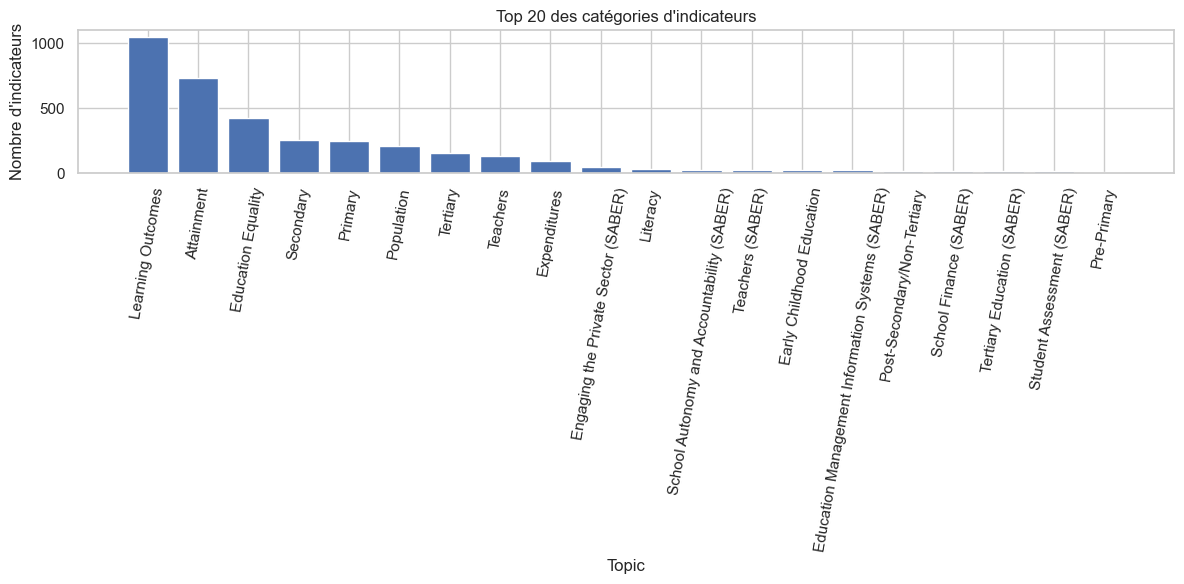

In [12]:
top_topics = series["Topic"].value_counts(dropna=False).head(20)
display(top_topics.to_frame(name="nb_indicateurs"))

plt.figure(figsize=(12, 6))
plt.bar(top_topics.index.astype(str), top_topics.values)
plt.title("Top 20 des catégories d'indicateurs")
plt.xlabel("Topic")
plt.ylabel("Nombre d'indicateurs")
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

## Sélection métier des indicateurs

Après revue du dictionnaire `Series` et au regard de la problématique d’expansion, je retiens une première liste de 15 indicateurs couvrant :

- la connectivité numérique ;
- le niveau de développement ;
- l’accès à l’éducation ;
- l’investissement public ;
- la dynamique du marché ;
- la taille potentielle du pays.

In [13]:
indicateurs_selectionnes = [
    "SP.POP.TOTL",
    "NY.GDP.PCAP.CD",
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.TER.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SE.ADT.LITR.ZS",
    "UIS.X.TOTL.FSGOV",
    "SL.UEM.TOTL.ZS",
    "SP.URB.TOTL.IN.ZS",
    "SE.PRM.CMPT.ZS",
    "SE.SEC.CMPT.LO.ZS",
    "SE.TER.CUAT.BA.ZS",
    "IT.CEL.SETS.P2",
]

print("Nombre d'indicateurs sélectionnés :", len(indicateurs_selectionnes))
print(indicateurs_selectionnes)

Nombre d'indicateurs sélectionnés : 15
['SP.POP.TOTL', 'NY.GDP.PCAP.CD', 'IT.NET.USER.P2', 'SE.PRM.ENRR', 'SE.SEC.ENRR', 'SE.TER.ENRR', 'SE.XPD.TOTL.GD.ZS', 'SE.ADT.LITR.ZS', 'UIS.X.TOTL.FSGOV', 'SL.UEM.TOTL.ZS', 'SP.URB.TOTL.IN.ZS', 'SE.PRM.CMPT.ZS', 'SE.SEC.CMPT.LO.ZS', 'SE.TER.CUAT.BA.ZS', 'IT.CEL.SETS.P2']


## Filtrage des tables sur les indicateurs retenus

Je filtre maintenant toutes les tables utiles pour ne garder que ces indicateurs.

Cette étape réduit fortement le périmètre de travail et rend la suite de l’analyse plus lisible.

In [14]:
footnote_series_col = "SeriesCode" if "SeriesCode" in footnote_clean.columns else "IndicatorCode"

series_filtre = series[series["Series Code"].isin(indicateurs_selectionnes)].copy()
country_series_filtre = country_series_clean[country_series_clean["SeriesCode"].isin(indicateurs_selectionnes)].copy()
footnote_filtre = footnote_clean[footnote_clean[footnote_series_col].isin(indicateurs_selectionnes)].copy()
data_filtre = data_clean[data_clean["Indicator Code"].isin(indicateurs_selectionnes)].copy()

print("series_filtre         :", series_filtre.shape)
print("country_series_filtre :", country_series_filtre.shape)
print("footnote_filtre       :", footnote_filtre.shape)
print("data_filtre           :", data_filtre.shape)

series_filtre         : (11, 15)
country_series_filtre : (215, 3)
footnote_filtre       : (25934, 4)
data_filtre           : (2365, 69)


# 4. Réduction du périmètre des années

Le fichier `Data` contient une colonne par année.  
Certaines années futures correspondent à des projections et non à des observations.

Pour une aide à la décision, je privilégie un historique récent et suffisamment renseigné.

In [15]:
colonnes_annees = [col for col in data_filtre.columns if str(col).isdigit()]
colonnes_annees = sorted(colonnes_annees, key=int)

print("Premières années :", colonnes_annees[:10])
print("Dernières années :", colonnes_annees[-10:])
print("Nombre total de colonnes années :", len(colonnes_annees))

Premières années : ['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979']
Dernières années : ['2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090', '2095', '2100']
Nombre total de colonnes années : 65


## Taux de valeurs manquantes par année

Avec **Pandas**, la combinaison :

```python
data_filtre[colonnes_annees].isna().mean() * 100
```

fait les opérations suivantes :

- `isna()` transforme les valeurs manquantes en `True` ;
- `mean()` calcule la proportion de `True` par colonne ;
- `* 100` transforme cette proportion en pourcentage.

,pct_valeurs_manquantes
1970,78.139535
1971,61.775899
1972,62.367865
1973,62.621564
1974,62.663848
1975,62.114165
1976,60.718816
1977,60.887949
1978,61.014799
1979,60.634249


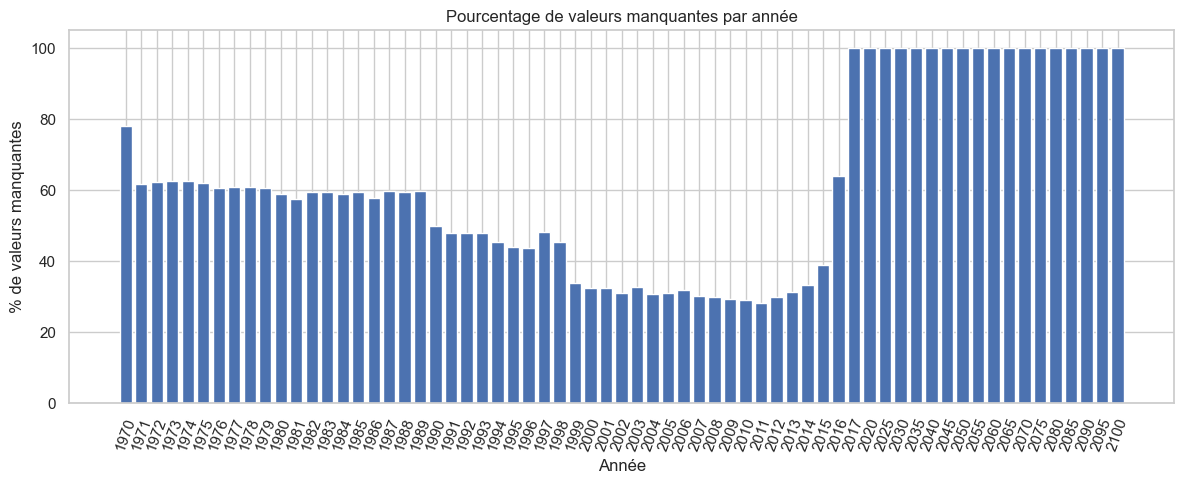

In [16]:
taux_nan_par_annee = data_filtre[colonnes_annees].isna().mean().sort_index() * 100
display(taux_nan_par_annee.to_frame(name="pct_valeurs_manquantes"))

plt.figure(figsize=(12, 5))
plt.bar(taux_nan_par_annee.index.astype(str), taux_nan_par_annee.values)
plt.title("Pourcentage de valeurs manquantes par année")
plt.xlabel("Année")
plt.ylabel("% de valeurs manquantes")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

Je conserve ici les années **2008 à 2017** :

- elles restent historiques ;
- elles sont plus récentes que le début du dataset ;
- elles permettent de calculer une statistique agrégée par pays et par indicateur.

In [17]:
annees_retenues = [str(y) for y in range(2008, 2018)]

data_filtre = data_filtre[
    ["Country Name", "Country Code", "Indicator Name", "Indicator Code"] + annees_retenues
].copy()

print("Shape de data_filtre après sélection des années :", data_filtre.shape)

Shape de data_filtre après sélection des années : (2365, 14)


# 5. Richesse des données

Je mesure maintenant la complétude des données :

- par année ;
- par indicateur ;
- par couple indicateur/année.

L’objectif est d’identifier les dimensions les plus exploitables.

## Proportion d’indicateurs renseignés par année

Ici, **Pandas** calcule pour chaque année la part de cellules non manquantes.

Cela permet de repérer les années les plus utilisables.

,proportion_renseignee
2008,0.699366
2009,0.707400
2010,0.709091
2011,0.717548
2012,0.700211
2013,0.687526
2014,0.667230
2015,0.611416
2016,0.359408
2017,0.000000


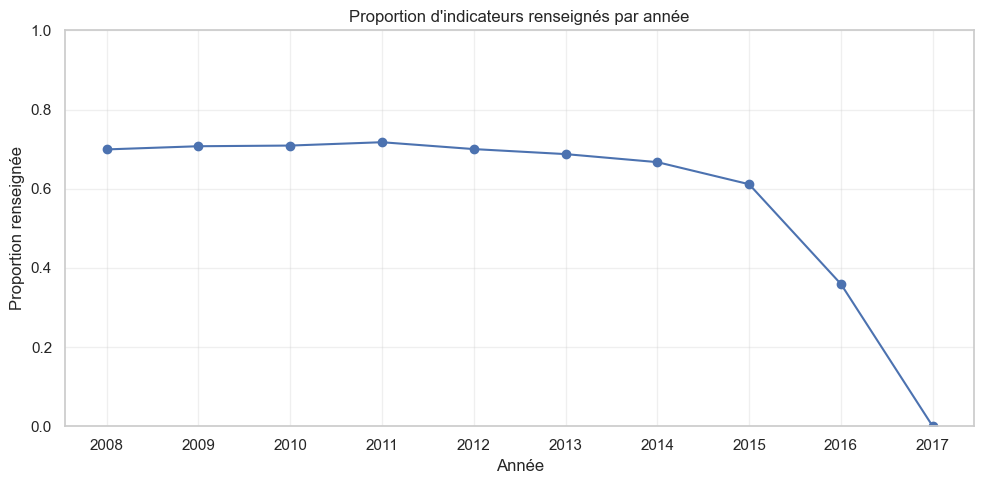

In [18]:
proportion_indicateurs_par_annee = data_filtre[annees_retenues].notna().mean()
display(proportion_indicateurs_par_annee.to_frame(name="proportion_renseignee"))

plt.figure(figsize=(10, 5))
plt.plot(proportion_indicateurs_par_annee.index.astype(str), proportion_indicateurs_par_annee.values, marker="o")
plt.title("Proportion d'indicateurs renseignés par année")
plt.xlabel("Année")
plt.ylabel("Proportion renseignée")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Proportion d’années renseignées par indicateur

Ici, j’utilise `groupby("Indicator Code")` pour regrouper les lignes par indicateur, puis une fonction `lambda` pour mesurer la complétude moyenne sur les années retenues.

,proportion_renseignee
Indicator Code,
SP.POP.TOTL,0.887907
IT.NET.USER.P2,0.842326
NY.GDP.PCAP.CD,0.833488
SL.UEM.TOTL.ZS,0.778605
SE.PRM.ENRR,0.594419
SE.SEC.ENRR,0.524186
SE.PRM.CMPT.ZS,0.492558
SE.TER.ENRR,0.473023
SE.SEC.CMPT.LO.ZS,0.466047


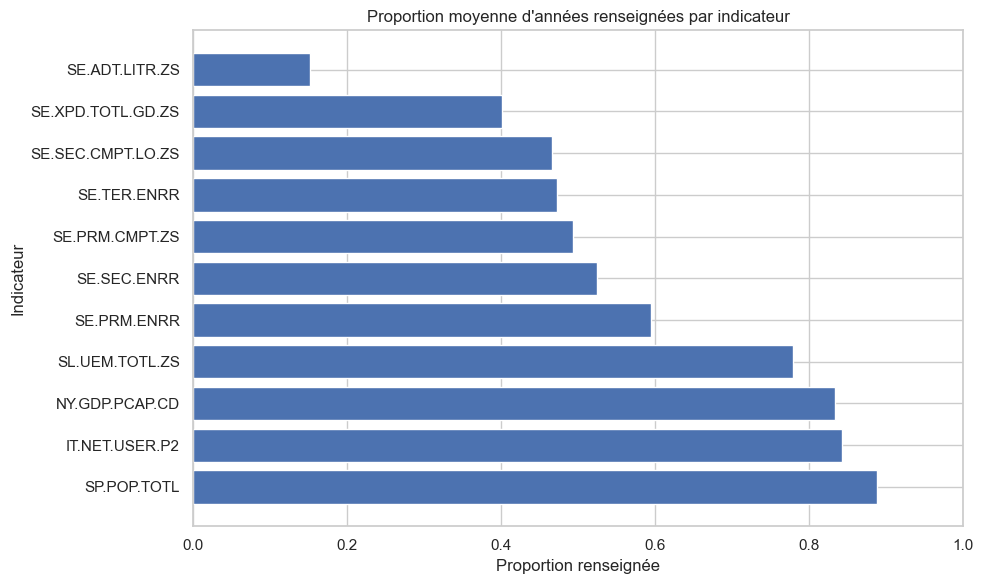

In [19]:
proportion_annees_par_indicateur = (
    data_filtre
    .groupby("Indicator Code")[annees_retenues]
    .apply(lambda df: df.notna().mean().mean())
    .sort_values(ascending=False)
)

display(proportion_annees_par_indicateur.to_frame(name="proportion_renseignee"))

plt.figure(figsize=(10, 6))
plt.barh(
    proportion_annees_par_indicateur.index.astype(str),
    proportion_annees_par_indicateur.values
)
plt.title("Proportion moyenne d'années renseignées par indicateur")
plt.xlabel("Proportion renseignée")
plt.ylabel("Indicateur")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Nombre de pays renseignés par indicateur et par année

Je passe d’abord la table du format large au format long avec `melt()`.

C’est une manipulation très utile en **Pandas** :
- les colonnes années deviennent une colonne `Year` ;
- les valeurs sont rassemblées dans une colonne `Value`.

Cela facilite ensuite les `groupby`.

In [20]:
df_long = data_filtre.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=annees_retenues,
    var_name="Year",
    value_name="Value"
)

df_pays_par_indicateur_annee = (
    df_long.dropna(subset=["Value"])
    .groupby(["Indicator Code", "Year"])["Country Code"]
    .nunique()
    .reset_index(name="nb_pays_renseignes")
    .sort_values(by="nb_pays_renseignes", ascending=False)
)

display(df_pays_par_indicateur_annee.head(20))

,Indicator Code,Year,nb_pays_renseignes
90,SP.POP.TOTL,2008,214
93,SP.POP.TOTL,2011,214
92,SP.POP.TOTL,2010,214
91,SP.POP.TOTL,2009,214
95,SP.POP.TOTL,2013,213
94,SP.POP.TOTL,2012,213
98,SP.POP.TOTL,2016,209
97,SP.POP.TOTL,2015,209
96,SP.POP.TOTL,2014,209
3,IT.NET.USER.P2,2011,203


# 6. Agrégation du fichier Data

Le fichier `Data` est à la maille :

**(pays, indicateur, année)**

Je construis maintenant un dataframe plus simple pour l’analyse finale :

- **une ligne = un pays**
- **une colonne = un indicateur**

Pour cela, j’agrège les années par la moyenne avec `pivot_table()`.

In [21]:
df_final = df_long.pivot_table(
    index=["Country Name", "Country Code"],
    columns="Indicator Code",
    values="Value",
    aggfunc="mean"
).reset_index()

print("Shape de df_final :", df_final.shape)
display(df_final.head())

Shape de df_final : (215, 13)


Indicator Code,Country Name,Country Code,IT.NET.USER.P2,NY.GDP.PCAP.CD,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,SE.PRM.ENRR,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,SE.TER.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
0,Afghanistan,AFG,5.733364,557.808008,31.74112,NaN,107.453099,NaN,52.435715,5.440723,3.334565,8.322222,3.082104e+07
1,Albania,ALB,51.181371,4257.272623,96.67697,99.054994,104.578660,93.178761,91.135354,50.202456,3.539440,14.866667,2.903828e+06
2,Algeria,DZA,22.239503,4805.519935,75.13605,102.623649,115.858408,75.343931,91.714499,32.652722,4.354250,10.622222,3.763989e+07
3,American Samoa,ASM,NaN,11245.413414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.570267e+04
4,Andorra,AND,86.860562,40699.204055,100.00000,NaN,NaN,NaN,NaN,NaN,3.005314,NaN,8.158444e+04


# 7. Analyse des corrélations

Je calcule les matrices de corrélation de **Pearson** et de **Spearman** pour repérer les indicateurs redondants.

- **Pearson** mesure surtout les relations linéaires ;
- **Spearman** mesure les relations monotones et est plus robuste à certaines distributions non normales.

In [22]:
indicateurs_df = df_final.drop(columns=["Country Name", "Country Code"])

corr_pearson = indicateurs_df.corr(method="pearson")
corr_spearman = indicateurs_df.corr(method="spearman")

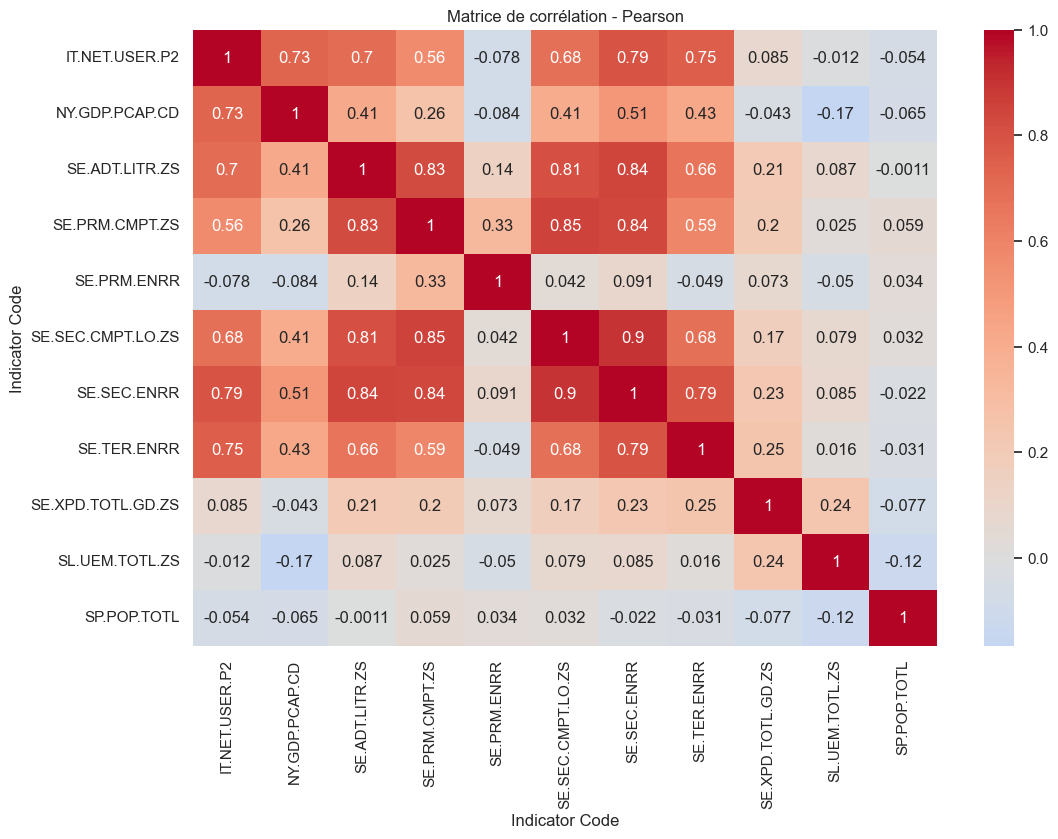

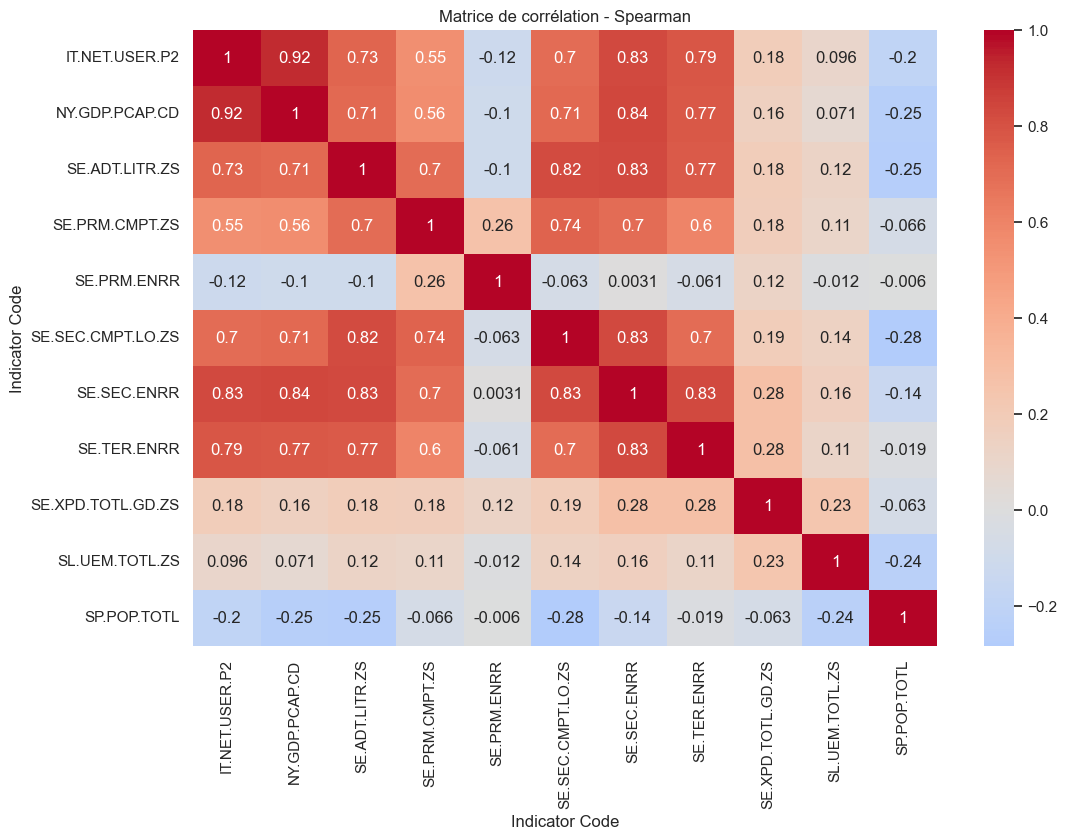

In [23]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Pearson")
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation - Spearman")
plt.show()

## Paires trop corrélées

Je liste les paires d’indicateurs dont la corrélation absolue dépasse `0.70`.

Cela permet de décider quels indicateurs conserver ou retirer.

In [24]:
def lister_paires_correlees(matrice_corr, seuil=0.70):
    colonnes = matrice_corr.columns
    resultats = []

    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):
            col1 = colonnes[i]
            col2 = colonnes[j]
            corr = matrice_corr.iloc[i, j]

            if pd.notna(corr) and abs(corr) > seuil:
                resultats.append({
                    "indicateur_1": col1,
                    "indicateur_2": col2,
                    "correlation": corr,
                    "correlation_absolue": abs(corr)
                })

    if len(resultats) == 0:
        return pd.DataFrame(columns=["indicateur_1", "indicateur_2", "correlation", "correlation_absolue"])

    return pd.DataFrame(resultats).sort_values(by="correlation_absolue", ascending=False)

seuil_corr = 0.70
paires_pearson = lister_paires_correlees(corr_pearson, seuil_corr)
paires_spearman = lister_paires_correlees(corr_spearman, seuil_corr)

print("Paires trop corrélées selon Pearson :")
display(paires_pearson)

print("Paires trop corrélées selon Spearman :")
display(paires_spearman)

Paires trop corrélées selon Pearson :


,indicateur_1,indicateur_2,correlation,correlation_absolue
8,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,0.897482,0.897482
6,SE.PRM.CMPT.ZS,SE.SEC.CMPT.LO.ZS,0.852789,0.852789
5,SE.ADT.LITR.ZS,SE.SEC.ENRR,0.844567,0.844567
7,SE.PRM.CMPT.ZS,SE.SEC.ENRR,0.837432,0.837432
3,SE.ADT.LITR.ZS,SE.PRM.CMPT.ZS,0.825667,0.825667
4,SE.ADT.LITR.ZS,SE.SEC.CMPT.LO.ZS,0.805217,0.805217
1,IT.NET.USER.P2,SE.SEC.ENRR,0.794776,0.794776
9,SE.SEC.ENRR,SE.TER.ENRR,0.792264,0.792264
2,IT.NET.USER.P2,SE.TER.ENRR,0.751998,0.751998
0,IT.NET.USER.P2,NY.GDP.PCAP.CD,0.726916,0.726916


Paires trop corrélées selon Spearman :


,indicateur_1,indicateur_2,correlation,correlation_absolue
0,IT.NET.USER.P2,NY.GDP.PCAP.CD,0.921922,0.921922
7,NY.GDP.PCAP.CD,SE.SEC.ENRR,0.836622,0.836622
10,SE.ADT.LITR.ZS,SE.SEC.ENRR,0.833078,0.833078
3,IT.NET.USER.P2,SE.SEC.ENRR,0.829708,0.829708
15,SE.SEC.ENRR,SE.TER.ENRR,0.828506,0.828506
13,SE.SEC.CMPT.LO.ZS,SE.SEC.ENRR,0.827089,0.827089
9,SE.ADT.LITR.ZS,SE.SEC.CMPT.LO.ZS,0.820265,0.820265
4,IT.NET.USER.P2,SE.TER.ENRR,0.788011,0.788011
8,NY.GDP.PCAP.CD,SE.TER.ENRR,0.774143,0.774143
11,SE.ADT.LITR.ZS,SE.TER.ENRR,0.766810,0.766810


## Sélection finale des indicateurs décorrélés

Après analyse des corrélations et arbitrage métier, je conserve 6 indicateurs :

- `IT.NET.USER.P2`
- `SE.PRM.ENRR`
- `SE.SEC.ENRR`
- `SE.XPD.TOTL.GD.ZS`
- `SL.UEM.TOTL.ZS`
- `SP.POP.TOTL`

Ils couvrent plusieurs dimensions utiles tout en limitant la redondance.

In [25]:
indicateurs_finaux = [
    "IT.NET.USER.P2",
    "SE.PRM.ENRR",
    "SE.SEC.ENRR",
    "SE.XPD.TOTL.GD.ZS",
    "SL.UEM.TOTL.ZS",
    "SP.POP.TOTL",
]

df_final_decorrele = df_final[["Country Name", "Country Code"] + indicateurs_finaux].copy()

print("Shape avant :", df_final.shape)
print("Shape après :", df_final_decorrele.shape)
print("Indicateurs gardés :")
print(indicateurs_finaux)

display(df_final_decorrele.head())

Shape avant : (215, 13)
Shape après : (215, 8)
Indicateurs gardés :
['IT.NET.USER.P2', 'SE.PRM.ENRR', 'SE.SEC.ENRR', 'SE.XPD.TOTL.GD.ZS', 'SL.UEM.TOTL.ZS', 'SP.POP.TOTL']


Indicator Code,Country Name,Country Code,IT.NET.USER.P2,SE.PRM.ENRR,SE.SEC.ENRR,SE.XPD.TOTL.GD.ZS,SL.UEM.TOTL.ZS,SP.POP.TOTL
0,Afghanistan,AFG,5.733364,107.453099,52.435715,3.334565,8.322222,3.082104e+07
1,Albania,ALB,51.181371,104.578660,91.135354,3.539440,14.866667,2.903828e+06
2,Algeria,DZA,22.239503,115.858408,91.714499,4.354250,10.622222,3.763989e+07
3,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,5.570267e+04
4,Andorra,AND,86.860562,NaN,NaN,3.005314,NaN,8.158444e+04


# 8. Analyse univariée

Je calcule maintenant les statistiques descriptives de chaque indicateur et j’observe leur distribution.

La fonction ci-dessous combine :
- `describe()` pour les statistiques descriptives ;
- un histogramme Matplotlib ;
- un boxplot Matplotlib.

Le couple histogramme + boxplot permet de voir :
- la forme de la distribution ;
- l’étendue des valeurs ;
- la présence éventuelle d’outliers.

In [26]:
def analyser_indicateur(df, colonne):
    serie = df[colonne].dropna()

    print("=" * 70)
    print(f"Indicateur : {colonne}")
    print("=" * 70)
    display(serie.describe().to_frame(name=colonne))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(serie, bins=20)
    axes[0].set_title(f"Histogramme - {colonne}")
    axes[0].set_xlabel(colonne)
    axes[0].set_ylabel("Nombre de pays")

    axes[1].boxplot(serie, vert=False)
    axes[1].set_title(f"Boxplot - {colonne}")
    axes[1].set_xlabel(colonne)

    plt.tight_layout()
    plt.show()

Indicateur : IT.NET.USER.P2


,IT.NET.USER.P2
count,203.000000
mean,39.753781
std,27.561668
min,0.000000
25%,13.636175
50%,37.070576
75%,61.167009
max,95.507367


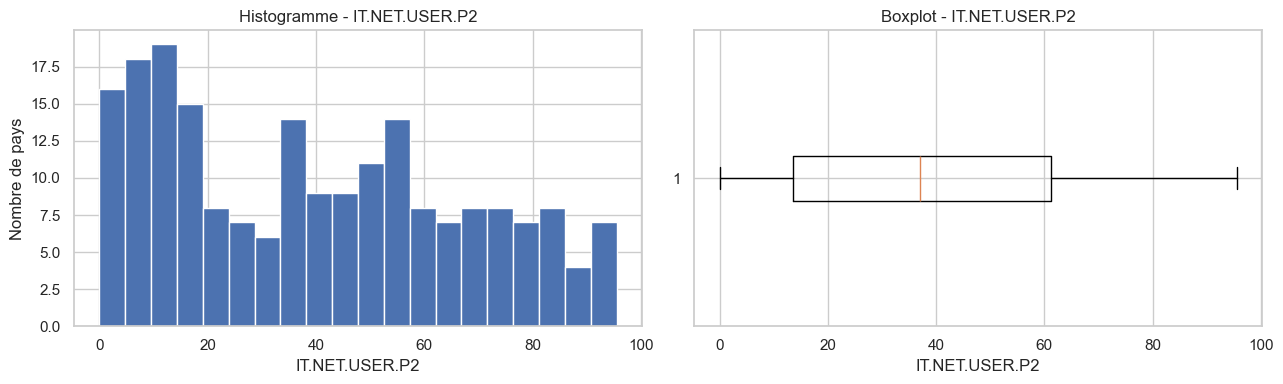

Indicateur : SE.PRM.ENRR


,SE.PRM.ENRR
count,189.000000
mean,104.169471
std,13.622134
min,52.764125
25%,99.015978
50%,103.509791
75%,109.357418
max,175.244186


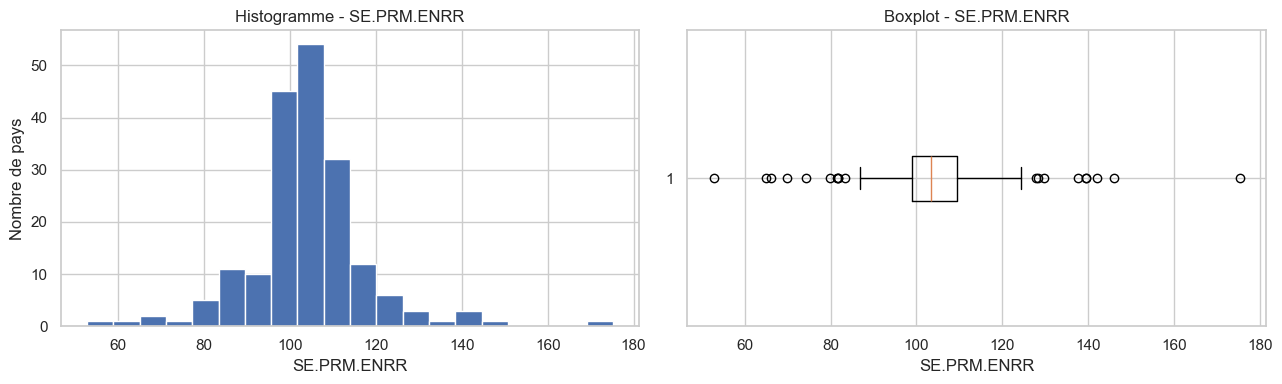

Indicateur : SE.SEC.ENRR


,SE.SEC.ENRR
count,181.000000
mean,80.139434
std,27.114889
min,9.266445
25%,59.919016
50%,89.154598
75%,99.033059
max,133.871905


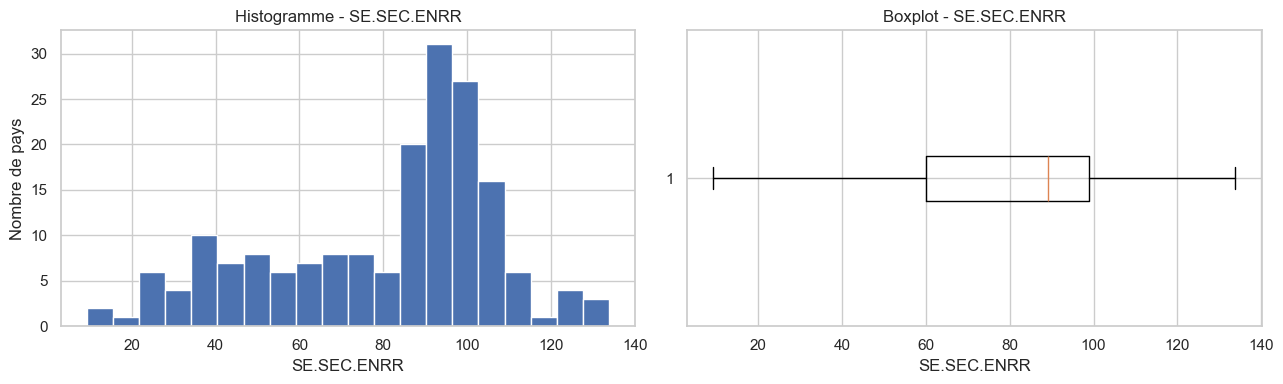

Indicateur : SE.XPD.TOTL.GD.ZS


,SE.XPD.TOTL.GD.ZS
count,171.000000
mean,4.651199
std,1.936001
min,1.099720
25%,3.299923
50%,4.566820
75%,5.565119
max,13.340503


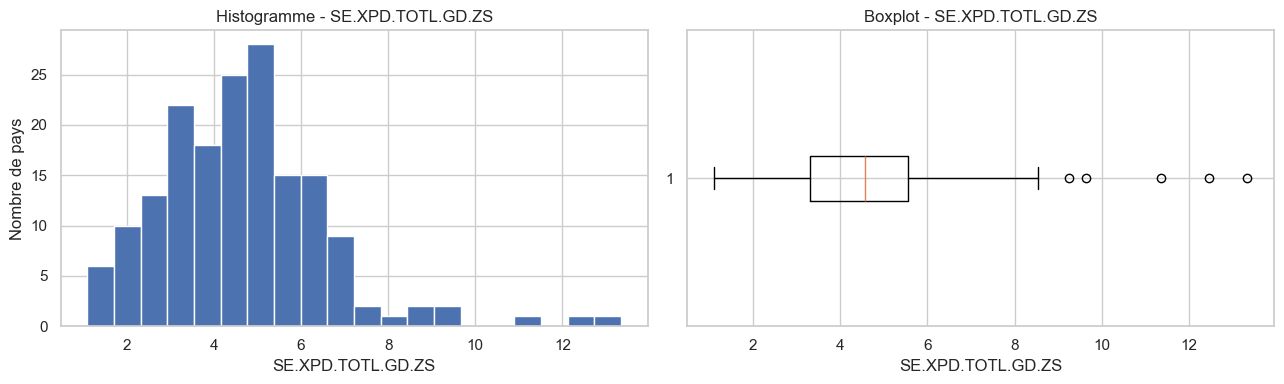

Indicateur : SL.UEM.TOTL.ZS


,SL.UEM.TOTL.ZS
count,186.000000
mean,8.902748
std,6.239065
min,0.233333
25%,4.966667
50%,6.988889
75%,11.533333
max,31.111111


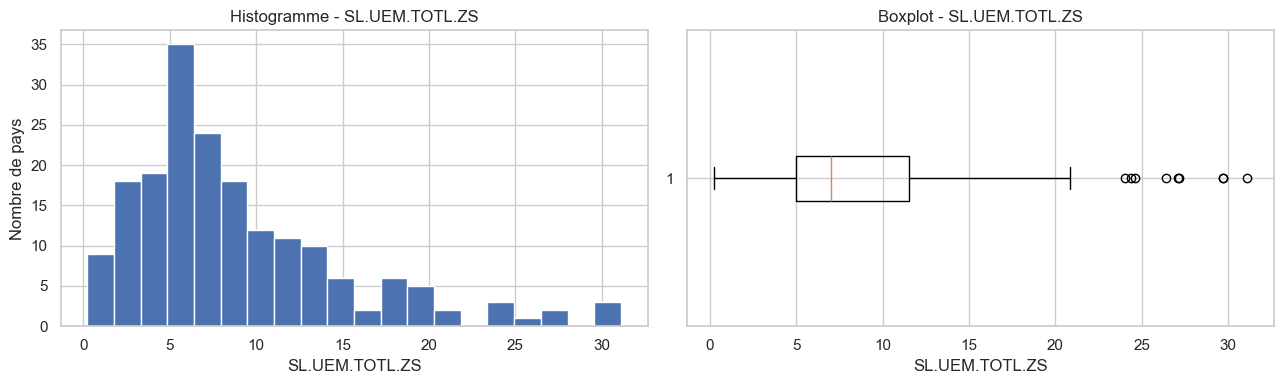

Indicateur : SP.POP.TOTL


,SP.POP.TOTL
count,2.140000e+02
mean,3.306520e+07
std,1.307670e+08
min,1.072111e+04
25%,8.748263e+05
50%,6.204361e+06
75%,2.140103e+07
max,1.351109e+09


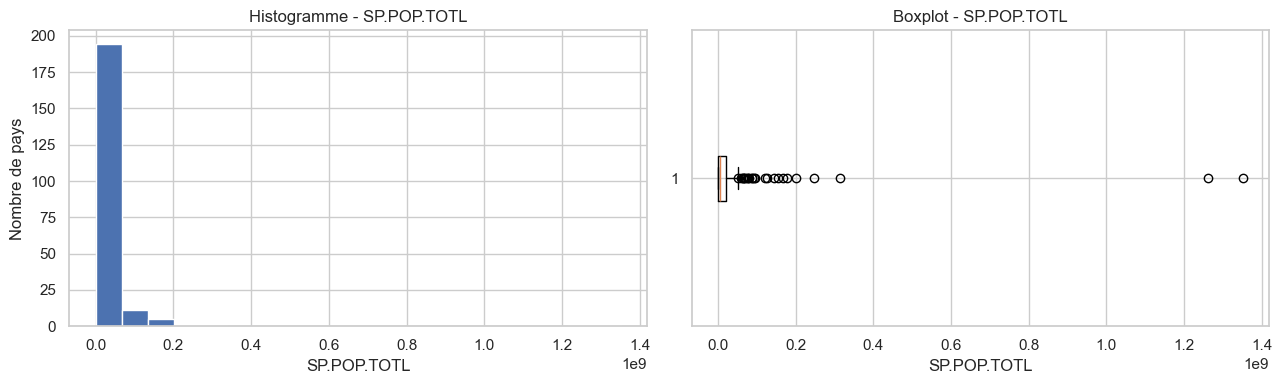

In [27]:
for col in indicateurs_finaux:
    analyser_indicateur(df_final_decorrele, col)

## Interprétation synthétique des distributions

- `IT.NET.USER.P2` distingue bien les pays très connectés des pays moins avancés numériquement.
- `SE.PRM.ENRR` est souvent élevé, donc moins discriminant seul.
- `SE.SEC.ENRR` apporte davantage de variation entre pays.
- `SE.XPD.TOTL.GD.ZS` mesure l’effort public consacré à l’éducation.
- `SL.UEM.TOTL.ZS` est un indicateur défavorable : plus il est élevé, moins l’environnement paraît attractif.
- `SP.POP.TOTL` permet d’intégrer la taille potentielle du marché, mais sa distribution est très asymétrique.

# 9. Méthode quantitative de sélection des pays

Je construis un **score composite** en quatre étapes :

1. normalisation min-max des indicateurs ;
2. inversion du chômage ;
3. pondération des dimensions ;
4. classement des pays.

## Pourquoi NumPy ici ?

`NumPy` permet de vectoriser les calculs, c’est-à-dire de traiter des colonnes entières très efficacement sans boucle complexe.  
Je l’utilise ici pour sécuriser la normalisation et le calcul du score.

In [28]:
df_score = df_final_decorrele.copy()

# Normalisation min-max : chaque indicateur est ramené entre 0 et 1
for col in indicateurs_finaux:
    min_val = df_score[col].min()
    max_val = df_score[col].max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        df_score[col + "_norm"] = np.nan
    else:
        df_score[col + "_norm"] = (df_score[col] - min_val) / (max_val - min_val)

# Le chômage est défavorable : plus il est faible, mieux c'est
df_score["SL.UEM.TOTL.ZS_norm"] = 1 - df_score["SL.UEM.TOTL.ZS_norm"]

poids = {
    "IT.NET.USER.P2_norm": 0.25,
    "SE.PRM.ENRR_norm": 0.10,
    "SE.SEC.ENRR_norm": 0.20,
    "SE.XPD.TOTL.GD.ZS_norm": 0.15,
    "SL.UEM.TOTL.ZS_norm": 0.15,
    "SP.POP.TOTL_norm": 0.15,
}

colonnes_score = list(poids.keys())
vecteur_poids = np.array([poids[col] for col in colonnes_score])

# Remplissage temporaire à 0 pour calculer le score sans erreur,
# puis division par la somme des poids effectivement disponibles
matrice = df_score[colonnes_score].fillna(0).to_numpy()
masque_disponible = df_score[colonnes_score].notna().to_numpy().astype(float)

numerateur = matrice @ vecteur_poids
denominateur = masque_disponible @ vecteur_poids

df_score["score_pays"] = np.where(denominateur > 0, numerateur / denominateur, np.nan)
df_score = df_score.sort_values(by="score_pays", ascending=False)

top_pays = df_score[["Country Name", "Country Code", "score_pays"]].head(10).copy()
display(top_pays)

Indicator Code,Country Name,Country Code,score_pays
53,Denmark,DNK,0.670999
41,China,CHN,0.657670
144,Norway,NOR,0.656771
137,Netherlands,NLD,0.653960
86,Iceland,ISL,0.653243
185,Sweden,SWE,0.638399
10,Australia,AUS,0.629011
66,Finland,FIN,0.628221
139,New Zealand,NZL,0.620355
18,Belgium,BEL,0.619362


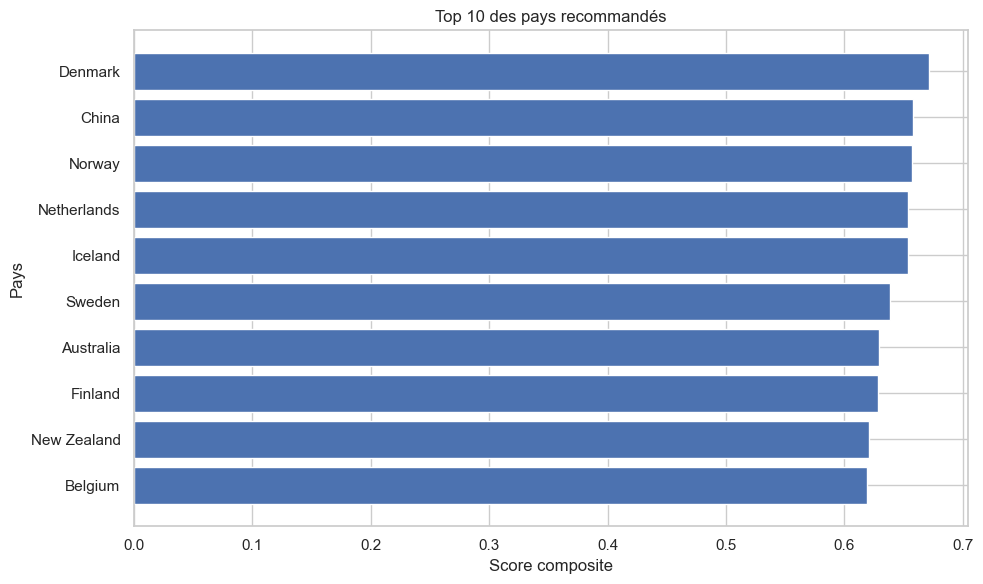

In [29]:
plt.figure(figsize=(10, 6))
plt.barh(top_pays["Country Name"][::-1], top_pays["score_pays"][::-1])
plt.title("Top 10 des pays recommandés")
plt.xlabel("Score composite")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()

# 10. Liste finale des pays favoris

L’affichage ci-dessous constitue la **liste finale des pays favoris / recommandés** à partir du score composite construit sur les indicateurs retenus.

In [30]:
top_pays_final = top_pays.reset_index(drop=True).copy()
top_pays_final.index = top_pays_final.index + 1
display(top_pays_final)

Indicator Code,Country Name,Country Code,score_pays
1,Denmark,DNK,0.670999
2,China,CHN,0.657670
3,Norway,NOR,0.656771
4,Netherlands,NLD,0.653960
5,Iceland,ISL,0.653243
6,Sweden,SWE,0.638399
7,Australia,AUS,0.629011
8,Finland,FIN,0.628221
9,New Zealand,NZL,0.620355
10,Belgium,BEL,0.619362


# 11. Conclusion

Les pays qui ressortent le plus sont majoritairement des pays :

- très connectés ;
- stables ;
- bien structurés sur le plan éducatif ;
- portés par de bons niveaux de développement.

Cette analyse constitue une **base de présélection** utile pour une décision d’expansion, mais elle doit être complétée par d’autres critères business :

- concurrence ;
- réglementation ;
- coût d’entrée ;
- stratégie commerciale propre à l’entreprise.

# 12. Export des résultats

Je sauvegarde :

- le dataframe final décorrélé ;
- la liste finale des pays recommandés.

In [31]:
df_final_decorrele.to_csv(base_path / "df_final_decorrele.csv", index=False)
top_pays_final.to_csv(base_path / "top_pays_recommandes.csv", index=False)

print("Fichiers exportés :")
print("-", base_path / "df_final_decorrele.csv")
print("-", base_path / "top_pays_recommandes.csv")

Fichiers exportés :
- /Users/vincentdesmouceaux/dev/P2_educatif_system_analysis/df_final_decorrele.csv
- /Users/vincentdesmouceaux/dev/P2_educatif_system_analysis/top_pays_recommandes.csv
